In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('data/rock_density_xray.csv')

In [5]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rebound Signal Strength nHz  300 non-null    float64
 1   Rock Density kg/m3           300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


<Axes: xlabel='Rebound Signal Strength nHz', ylabel='Rock Density kg/m3'>

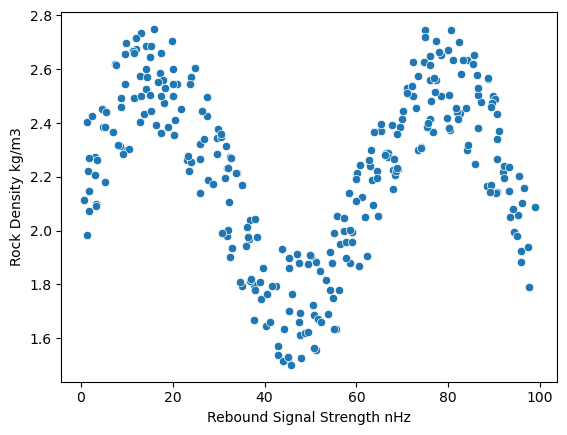

In [9]:
sns.scatterplot(df,y="Rock Density kg/m3",x="Rebound Signal Strength nHz")

In [28]:
df.columns=["Signal","Density"]

In [15]:
X=df.drop("Density",axis=1)#.values.reshape(-1,1)
y=df["Density"]

In [16]:
X

,Signal
0,72.945124
1,14.229877
2,36.597334
3,9.578899
4,21.765897
...,...
295,0.700227
296,58.586585
297,54.674548
298,15.162434


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lr_model = LinearRegression()

In [21]:
lr_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
lr_pred =lr_model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [24]:
MAE=mean_absolute_error(y_test,lr_pred)
RMSE=np.sqrt(mean_squared_error(y_test,lr_pred))

In [25]:
MAE

0.2499172902187054

In [26]:
RMSE

np.float64(0.2990483306477992)

In [42]:
signal_range=np.array(range(1,100))
signal_range

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

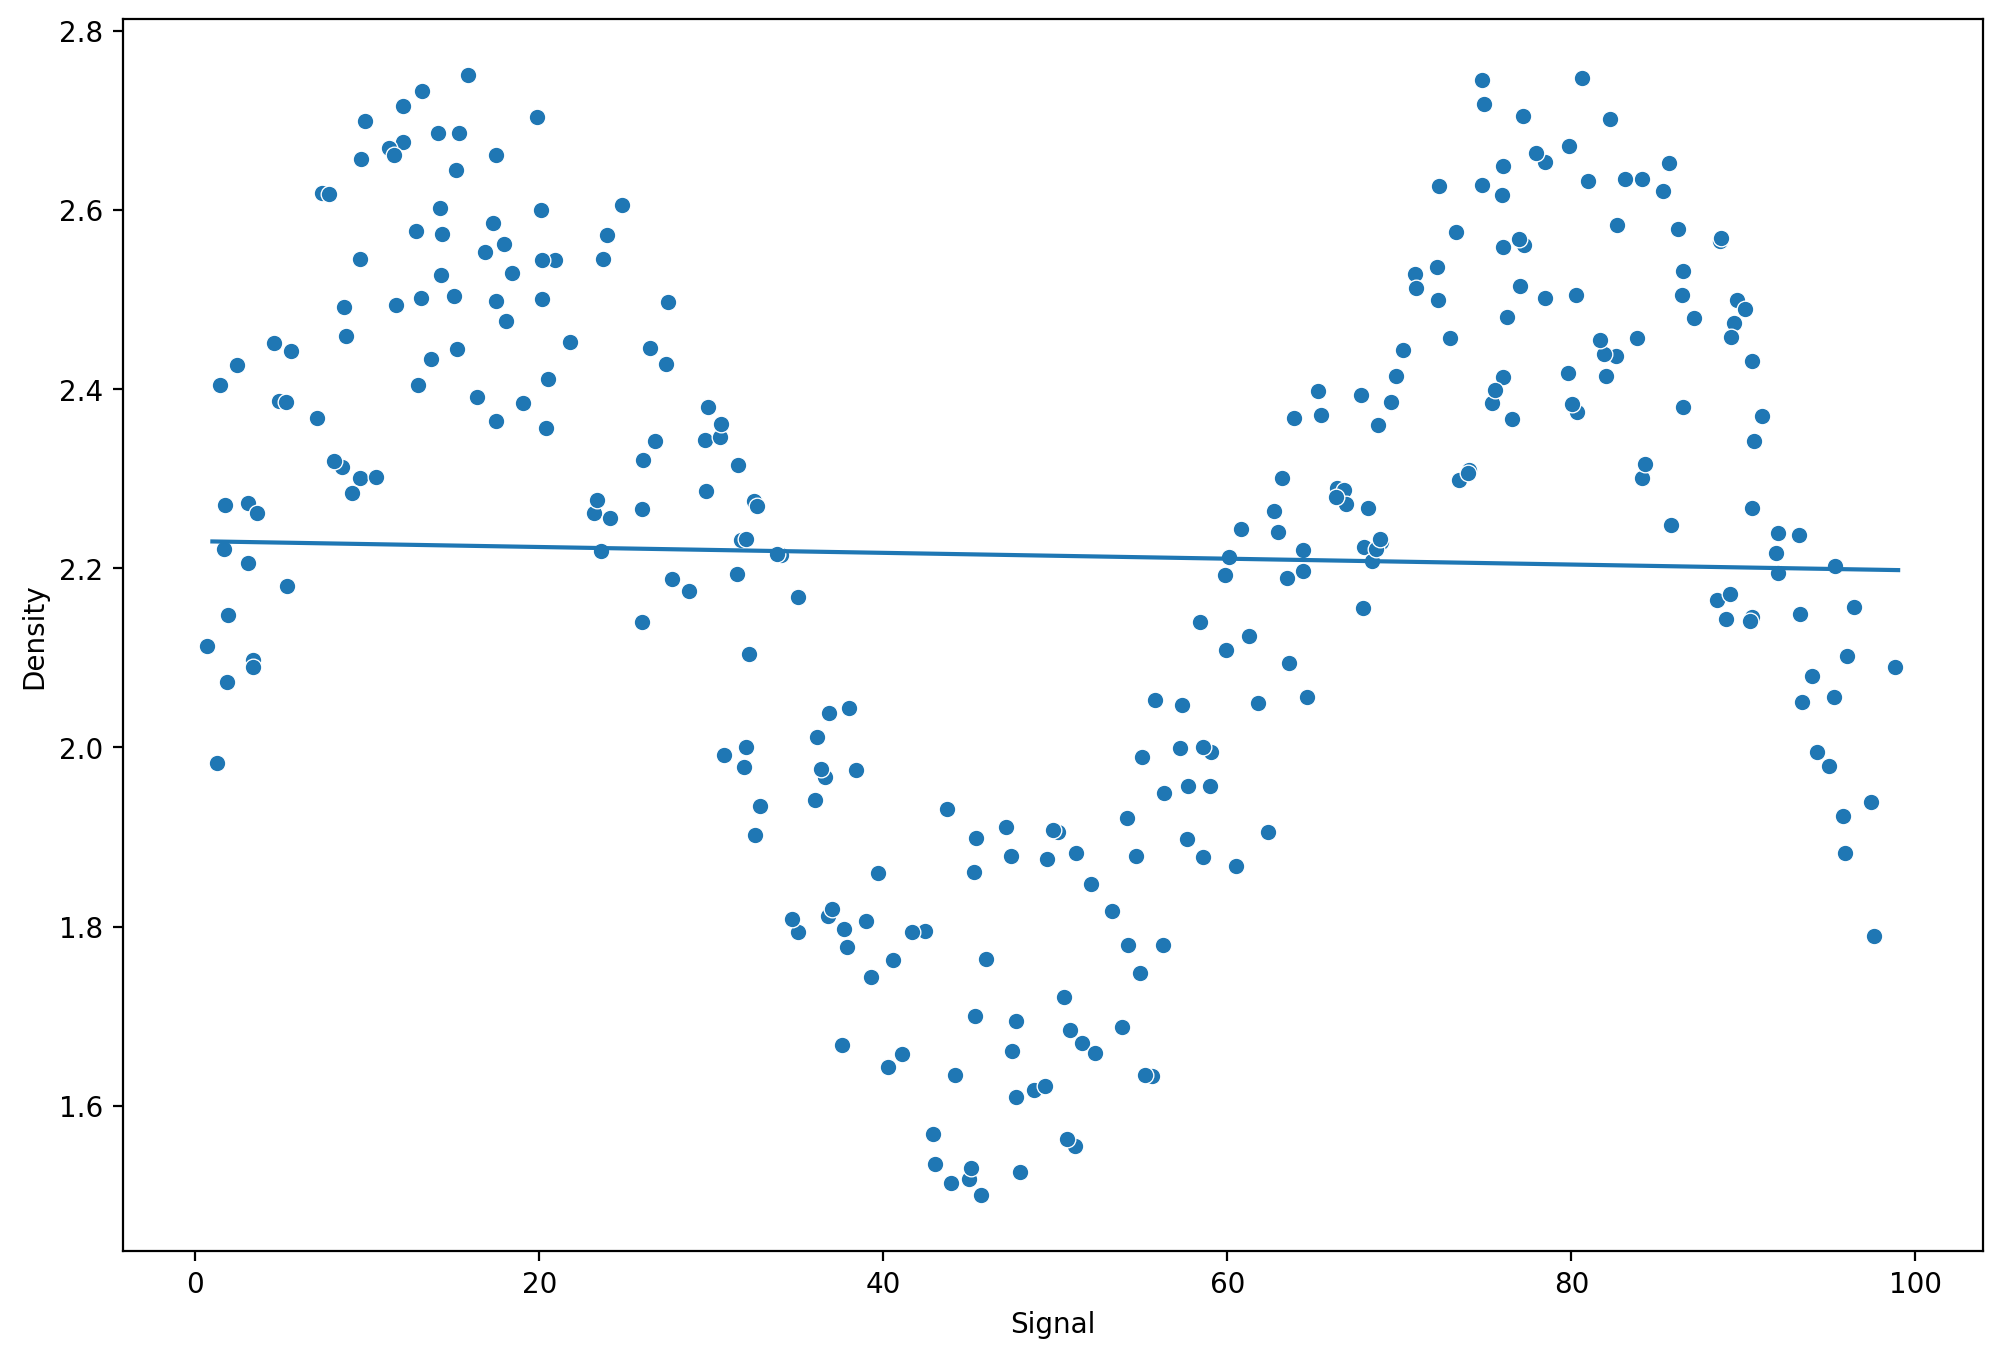

In [48]:
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Signal',y='Density',data=df)

plt.plot(signal_range,signal_preds)

In [47]:
signal_preds=lr_model.predict(signal_range.reshape(-1,1));

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [82]:
def run_model (model,X_train,y_train,X_test,y_test):
    #FIT MODEL TRAINING
    model.fit(X_train,y_train)

    #GET METRICS
    preds =model.predict(X_test) 
    rmse =np.sqrt(mean_squared_error(y_test,preds))
    mae =mean_absolute_error(y_test,preds)
    print(f'MAE:{mae}')
    print(f'RMSE:{rmse}')

    #PLOT RESULTS MODEL SIGNAL RANGE
    signal_range=np.arange(0,100)
    signal_preds =model.predict(signal_range.reshape(-1,1))

    plt.figure(figsize=(12,8),dpi=200)
    sns.scatterplot(x='Signal',y='Density',data=df,color='black')

    plt.plot(signal_range,signal_preds)
    

MAE:0.2499172902187054
RMSE:0.2990483306477992


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


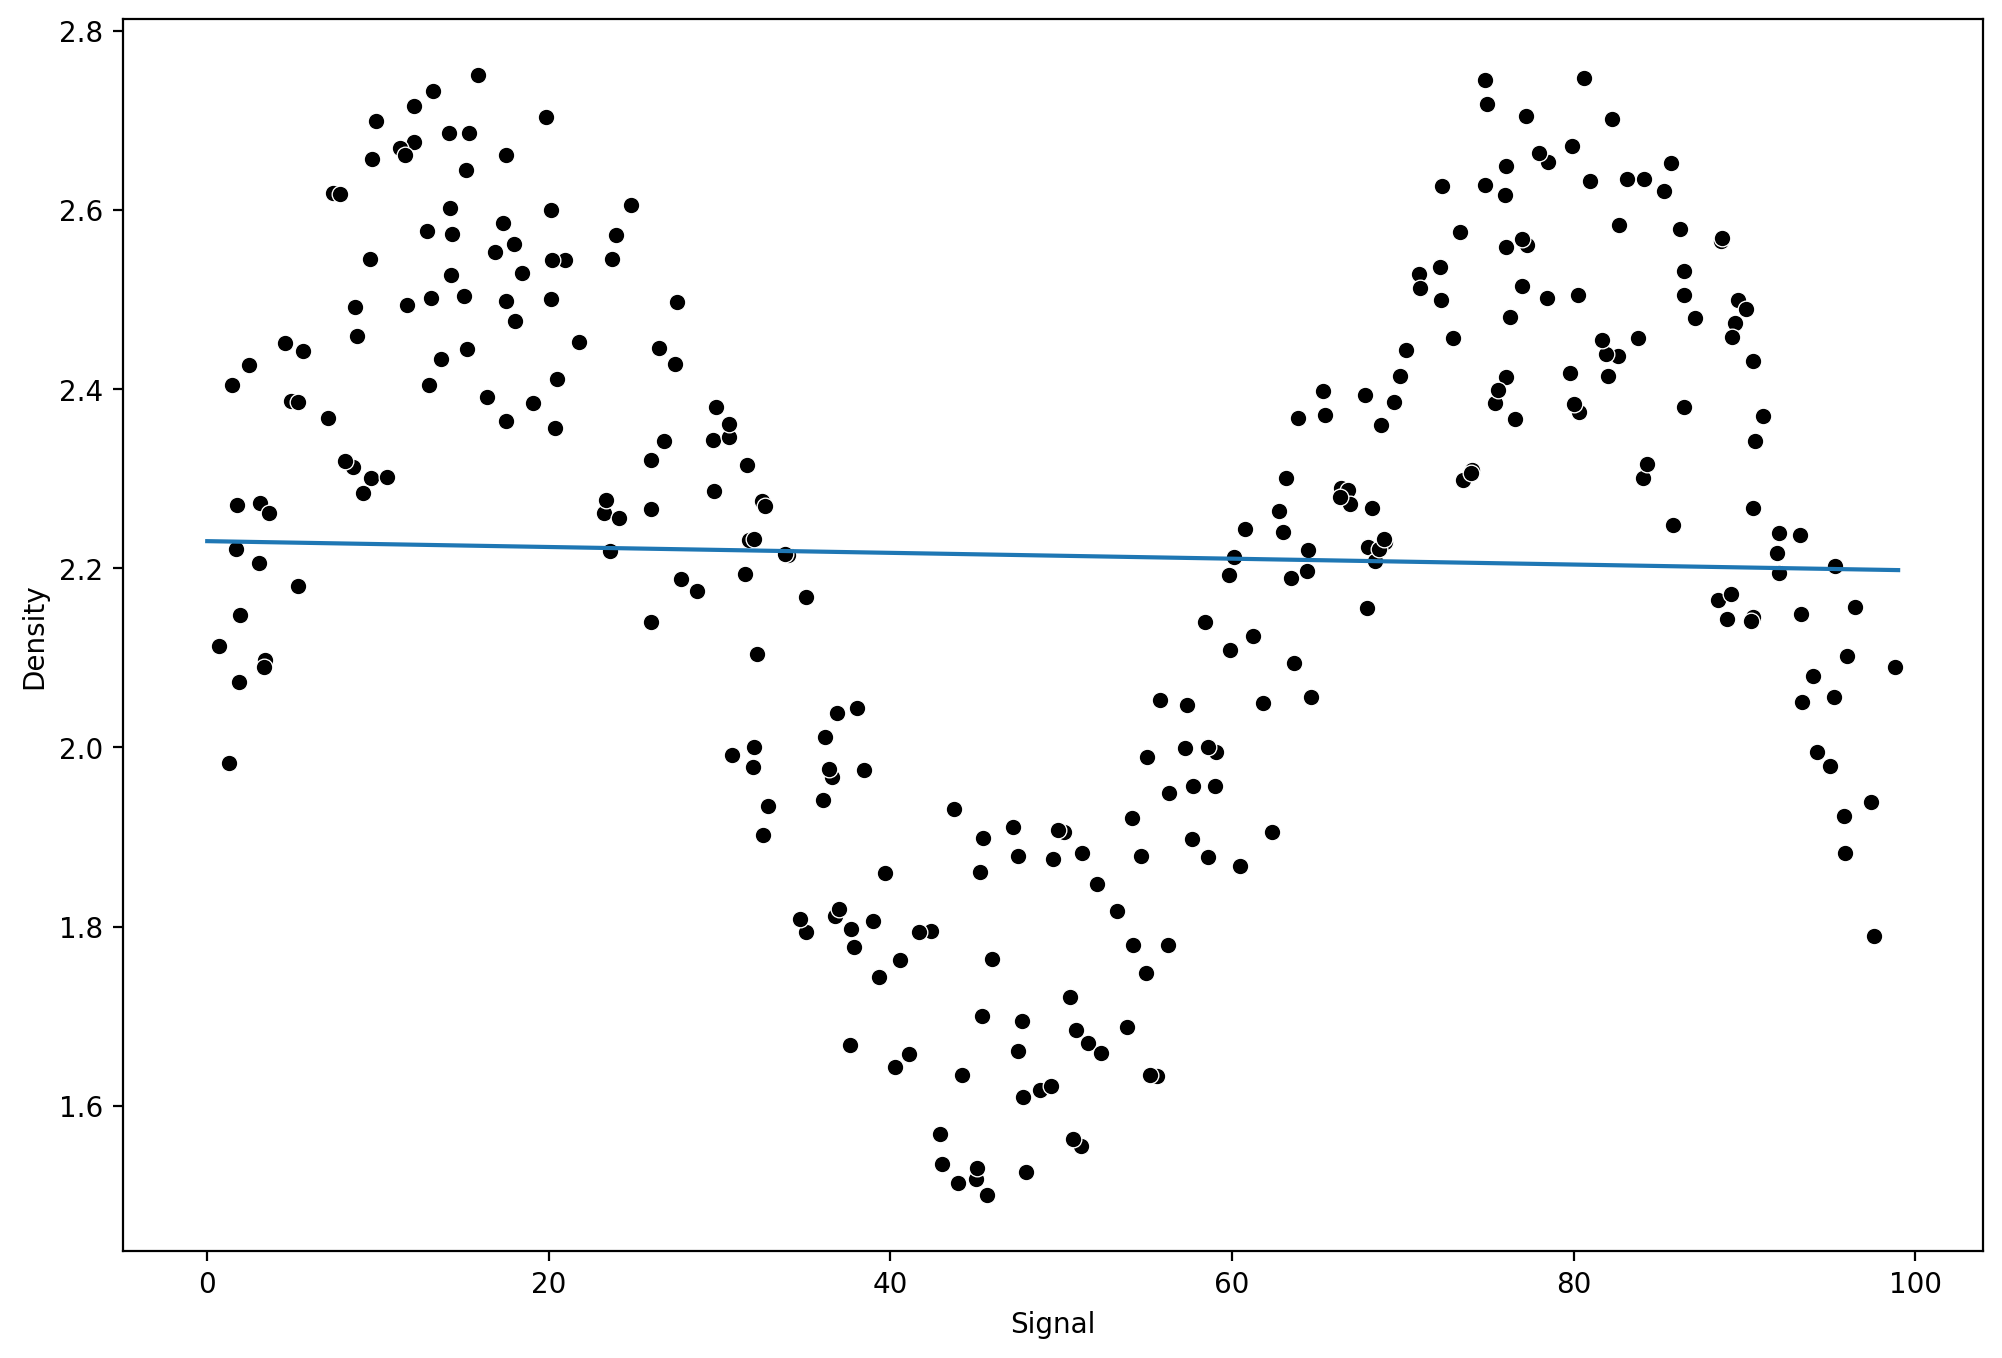

In [83]:
model=LinearRegression()
run_model(model,X_train,y_train,X_test,y_test)

In [84]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures



In [85]:
pipe=make_pipeline(PolynomialFeatures(degree=4),LinearRegression())

MAE:0.12933619614690456
RMSE:0.16500220567376492


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


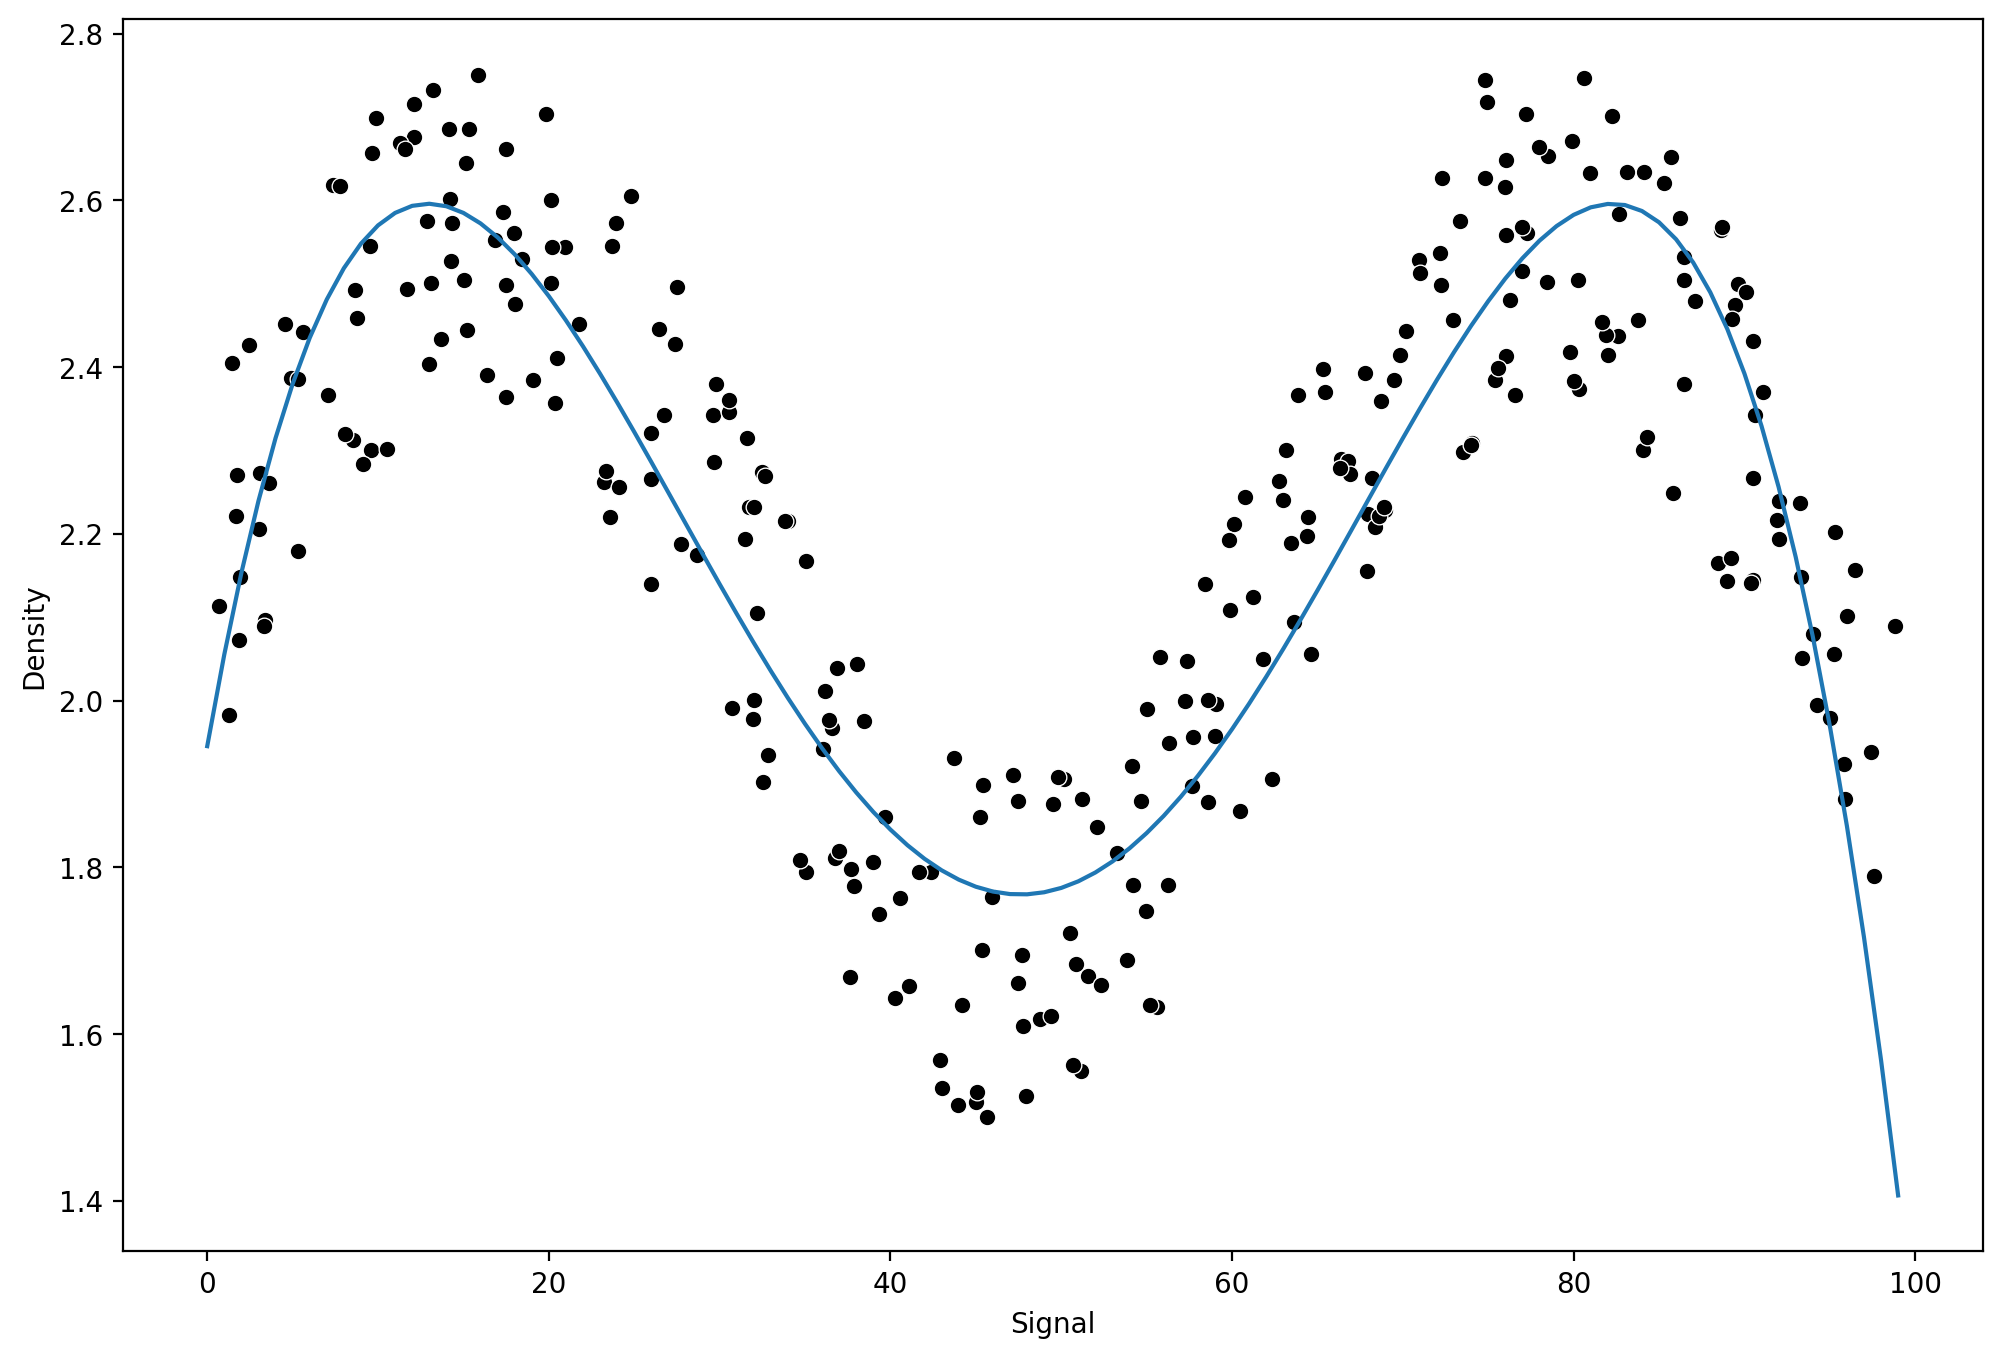

In [86]:
run_model(pipe,X_train,y_train,X_test,y_test)

In [87]:
from sklearn.neighbors import KNeighborsRegressor

MAE:0.14812000715430457
RMSE:0.1888824745783522
MAE:0.12318567278971365
RMSE:0.14455477938367722


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


MAE:0.11487576900908578
RMSE:0.13541344745637326


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


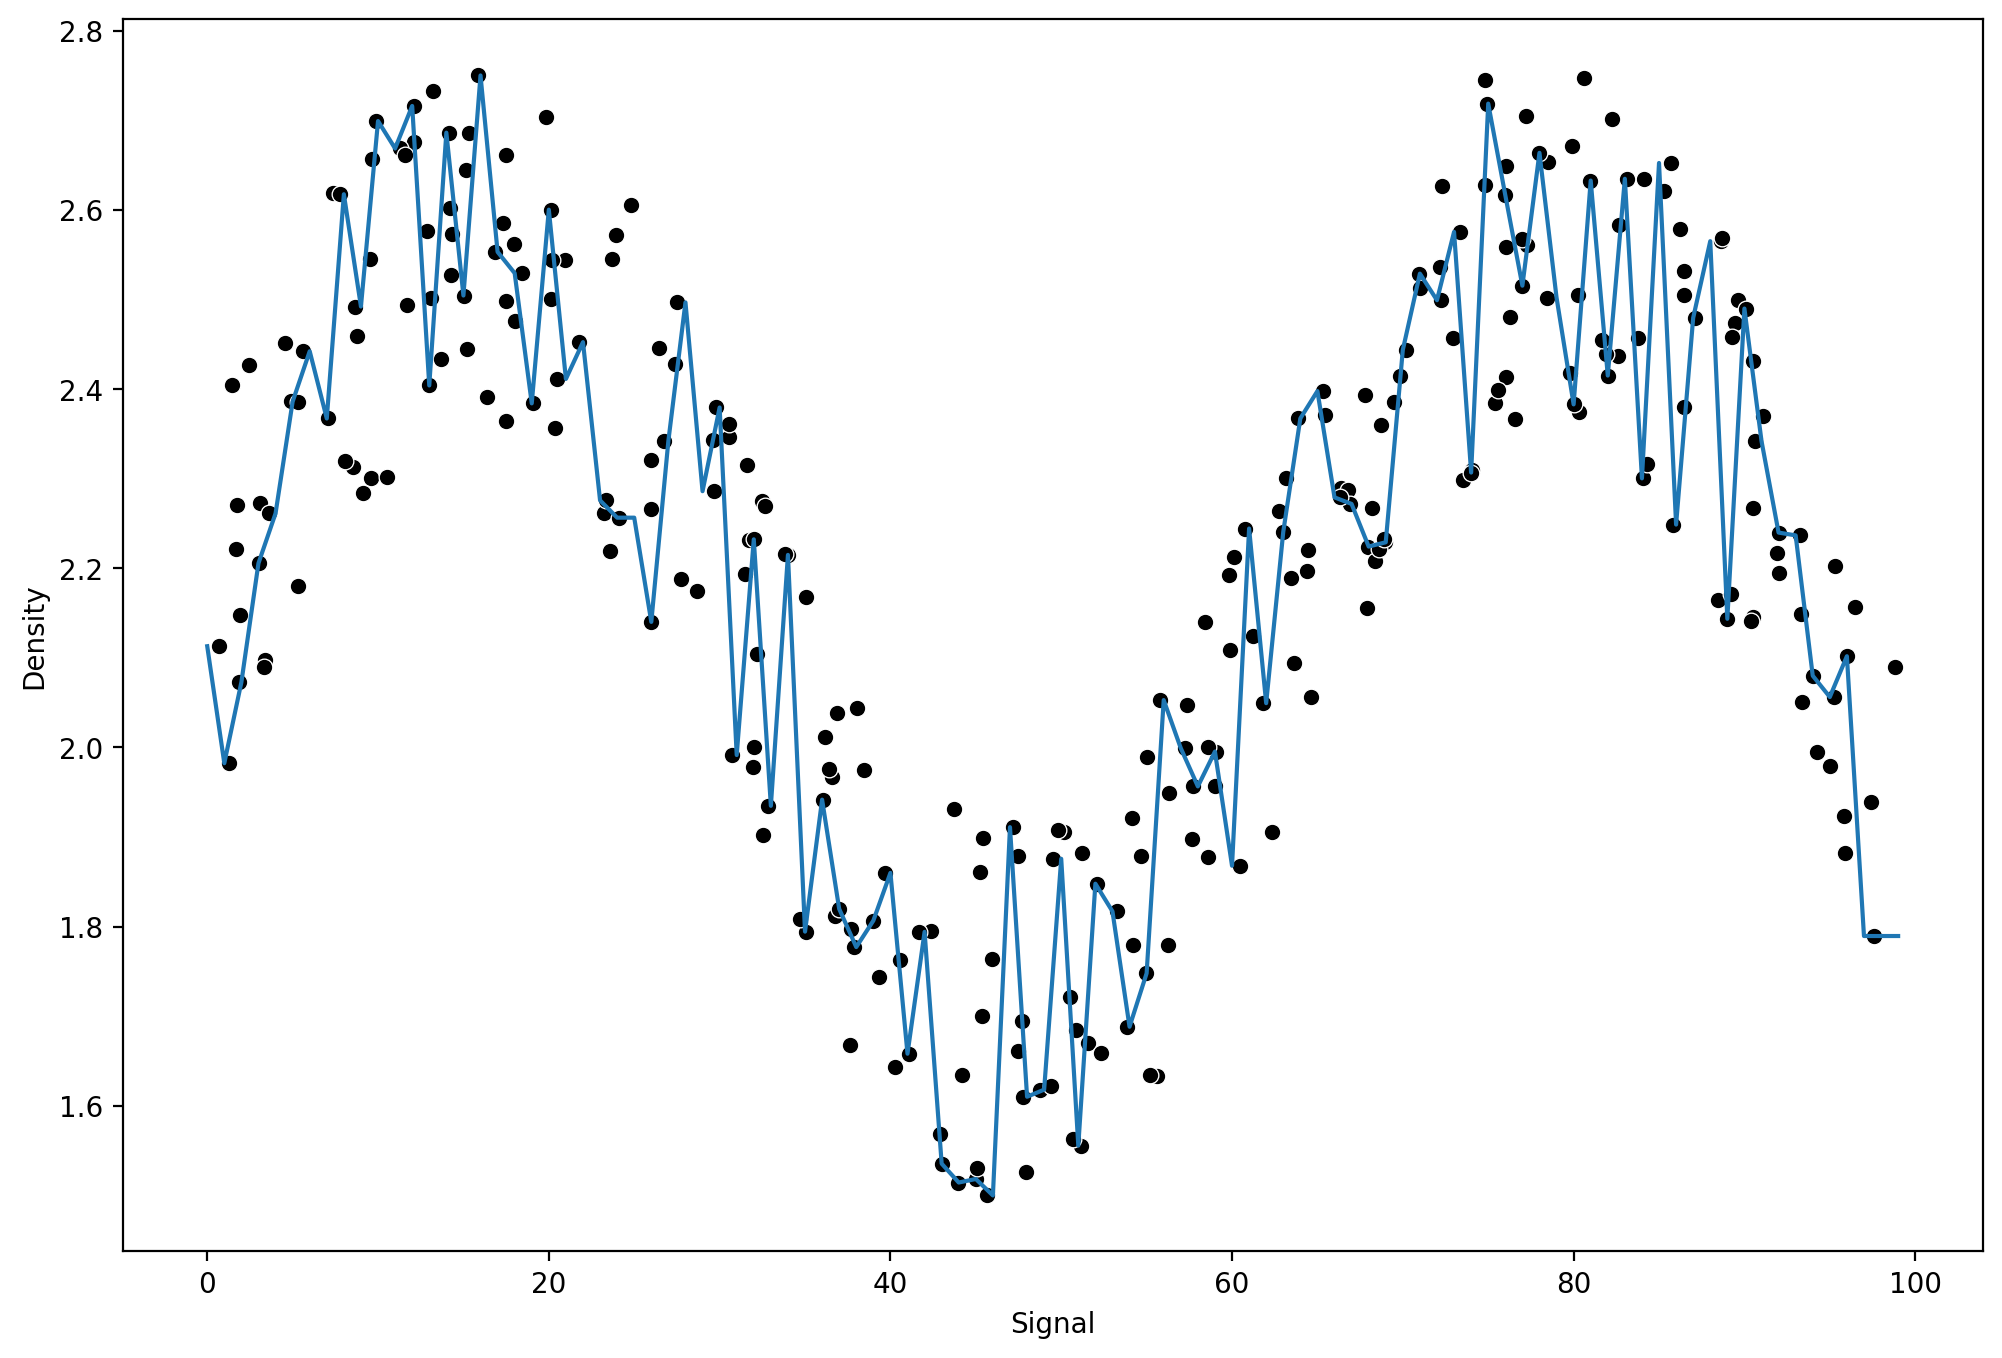

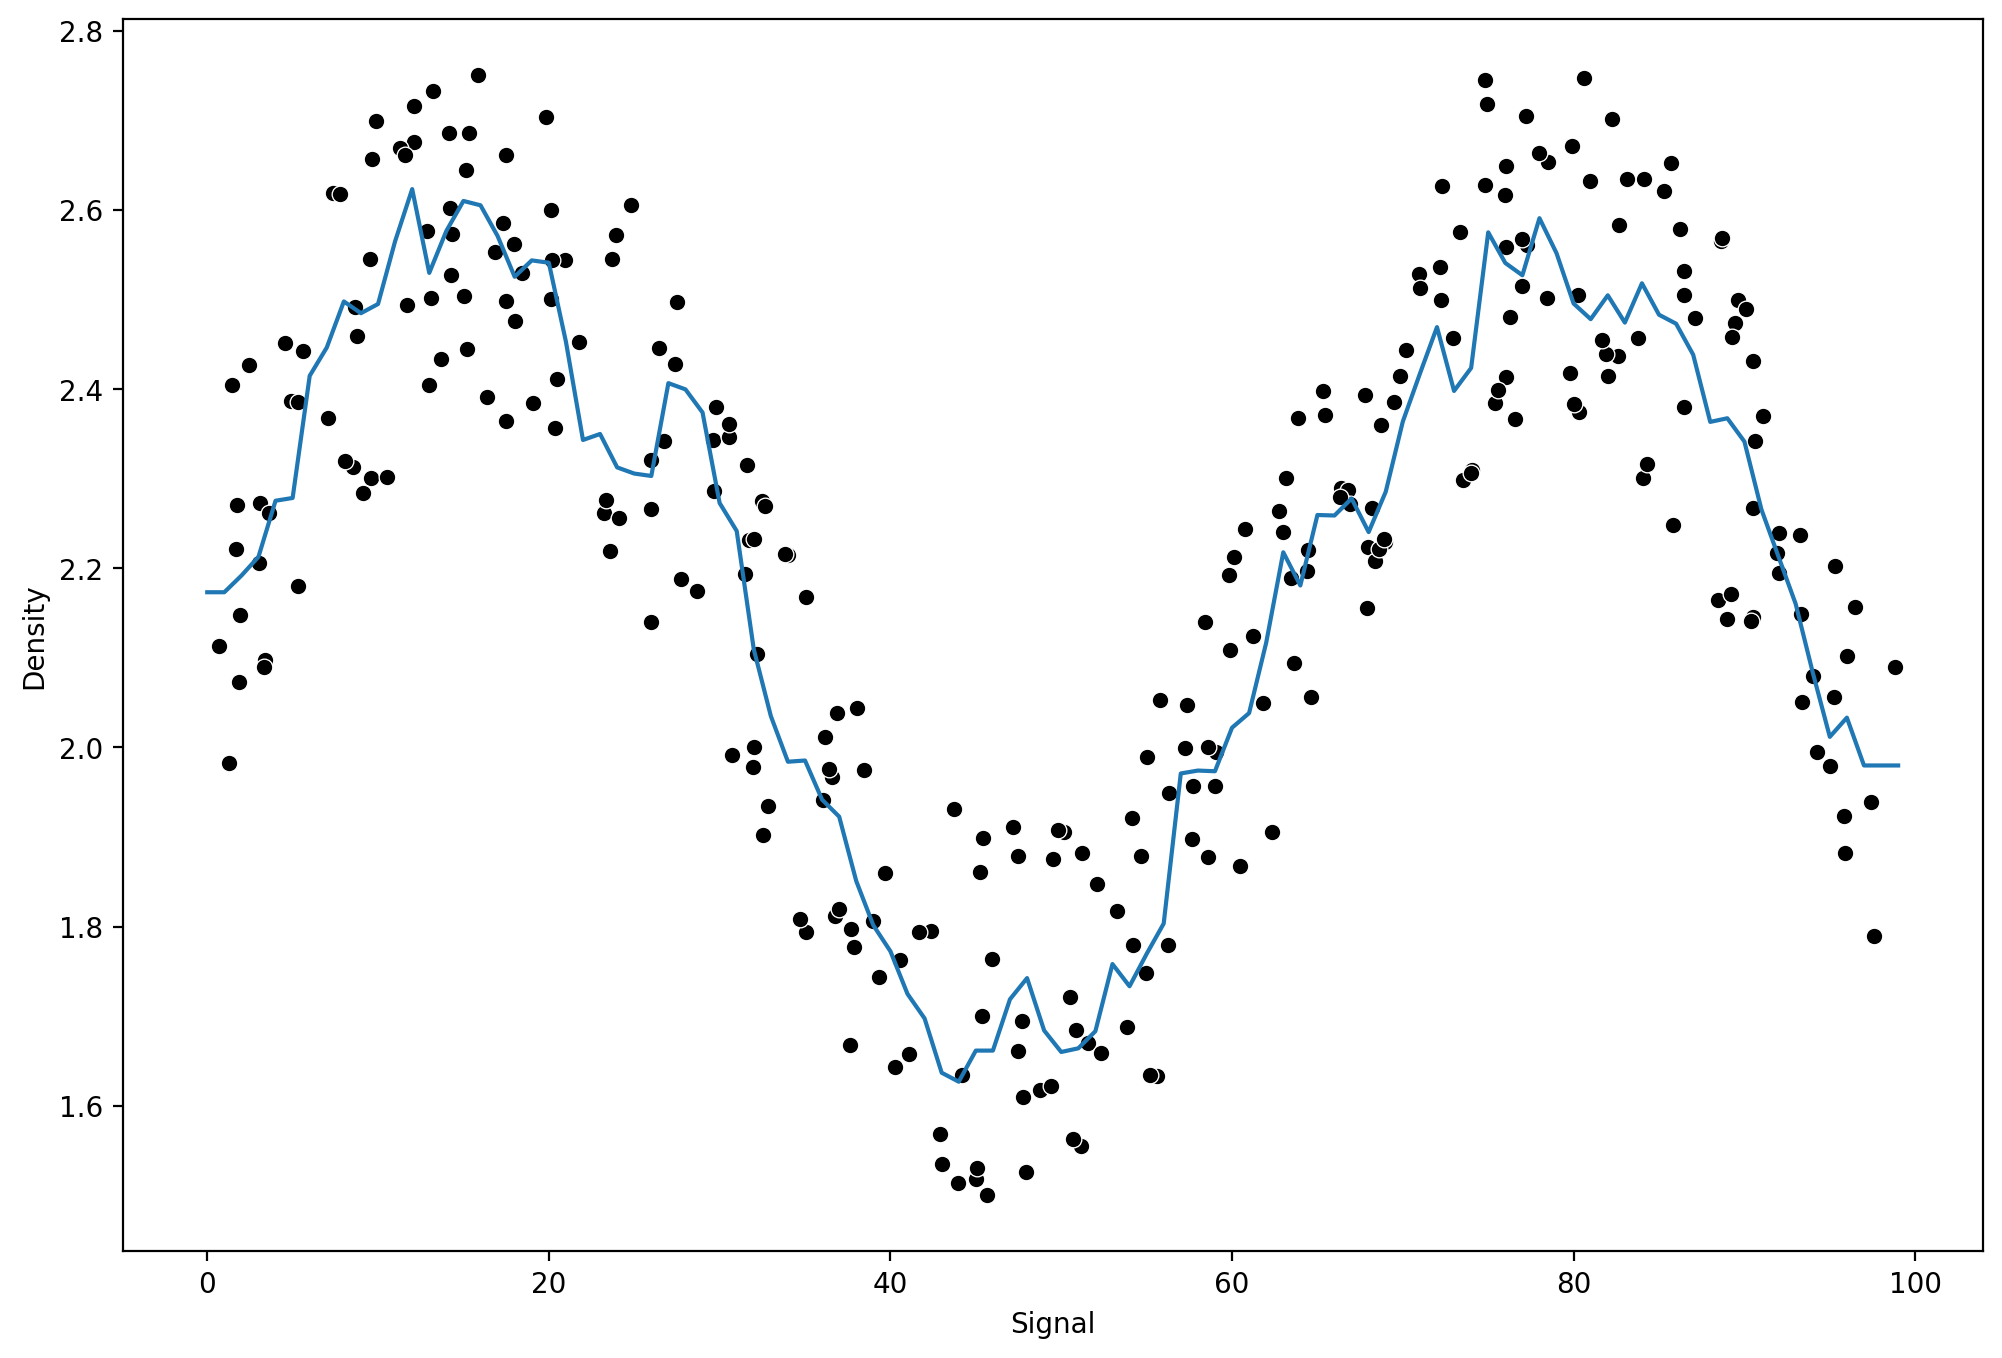

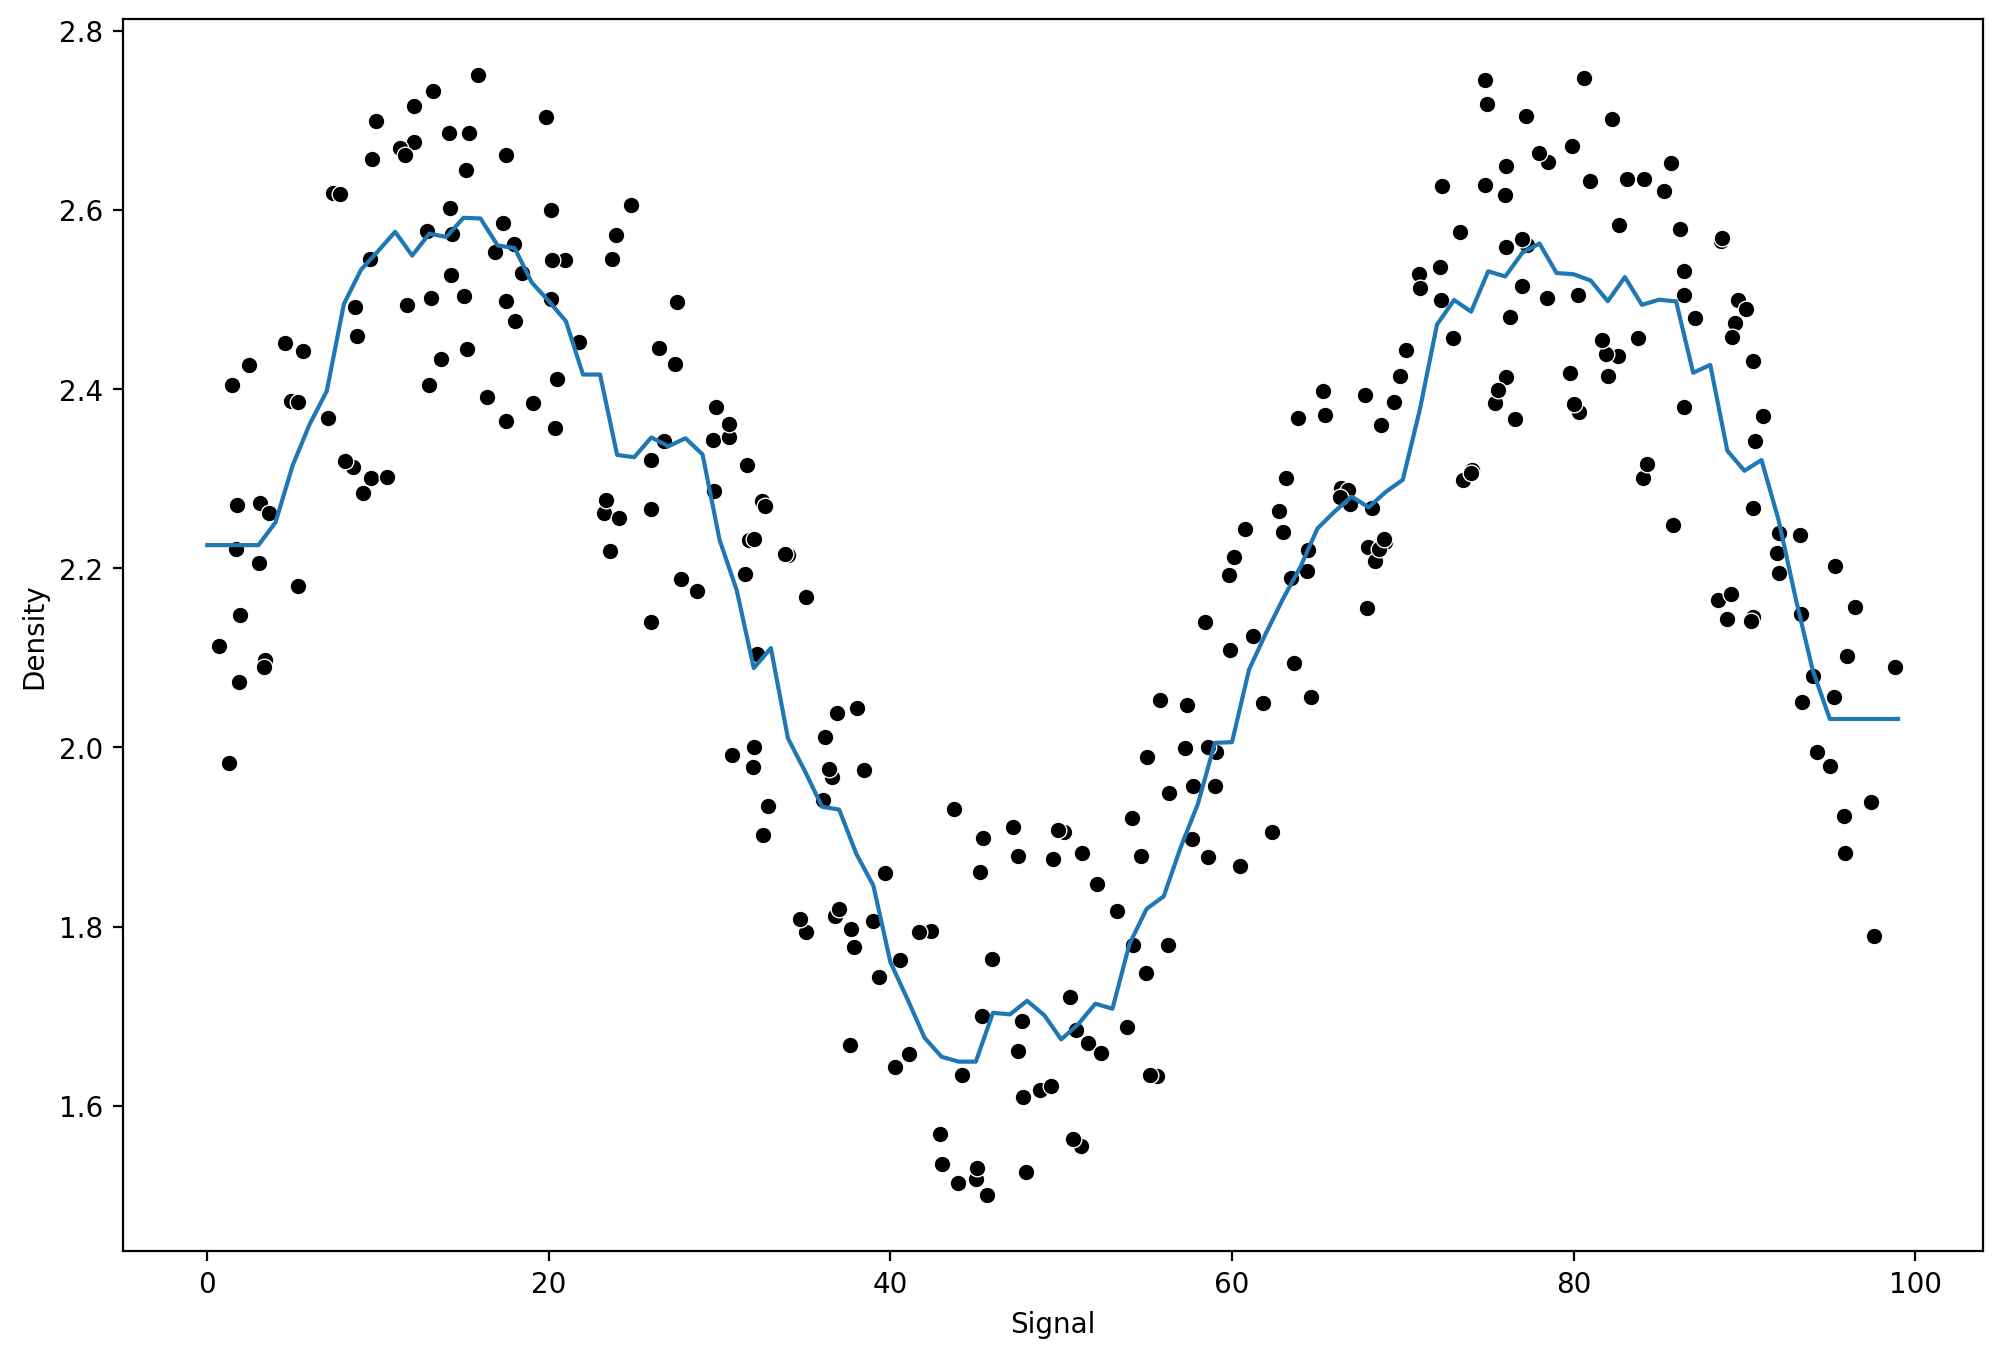

In [88]:
k_values=[1,5,10]
for n in k_values:
    model=KNeighborsRegressor(n_neighbors=n)
    run_model(model ,X_train,y_train,X_test,y_test)

In [89]:
from sklearn.tree import DecisionTreeRegressor

MAE:0.14812000715430457
RMSE:0.1888824745783522


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


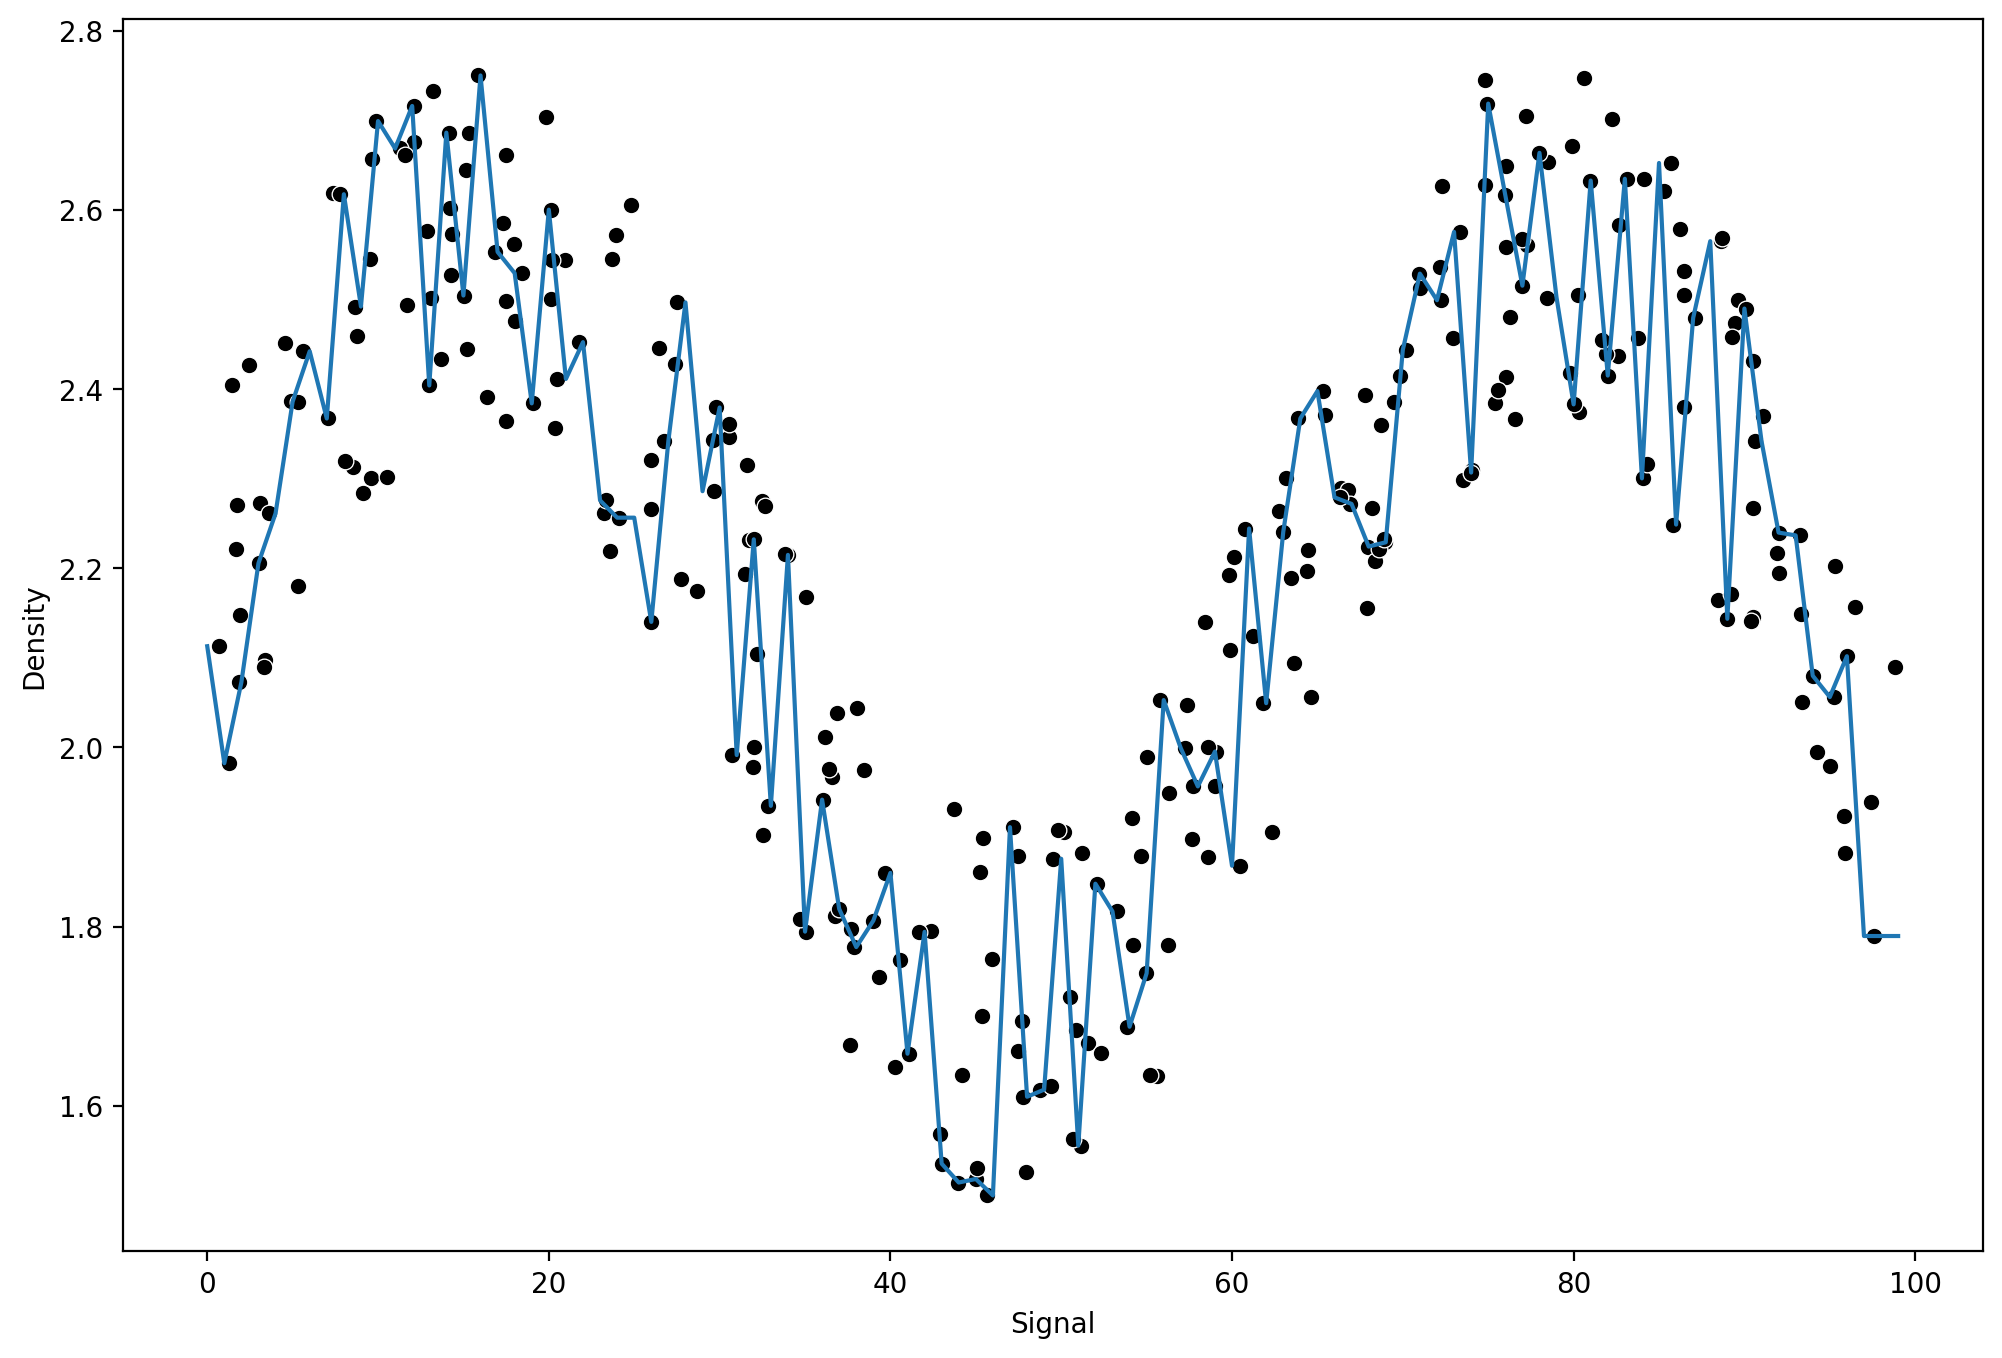

In [90]:
model=DecisionTreeRegressor()
run_model(model,X_train,y_train,X_test,y_test)

In [91]:
from sklearn.svm import SVR


In [92]:
from sklearn.model_selection import GridSearchCV

In [93]:
svr=SVR()

MAE:0.11565230883949644
RMSE:0.1366536012878494


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


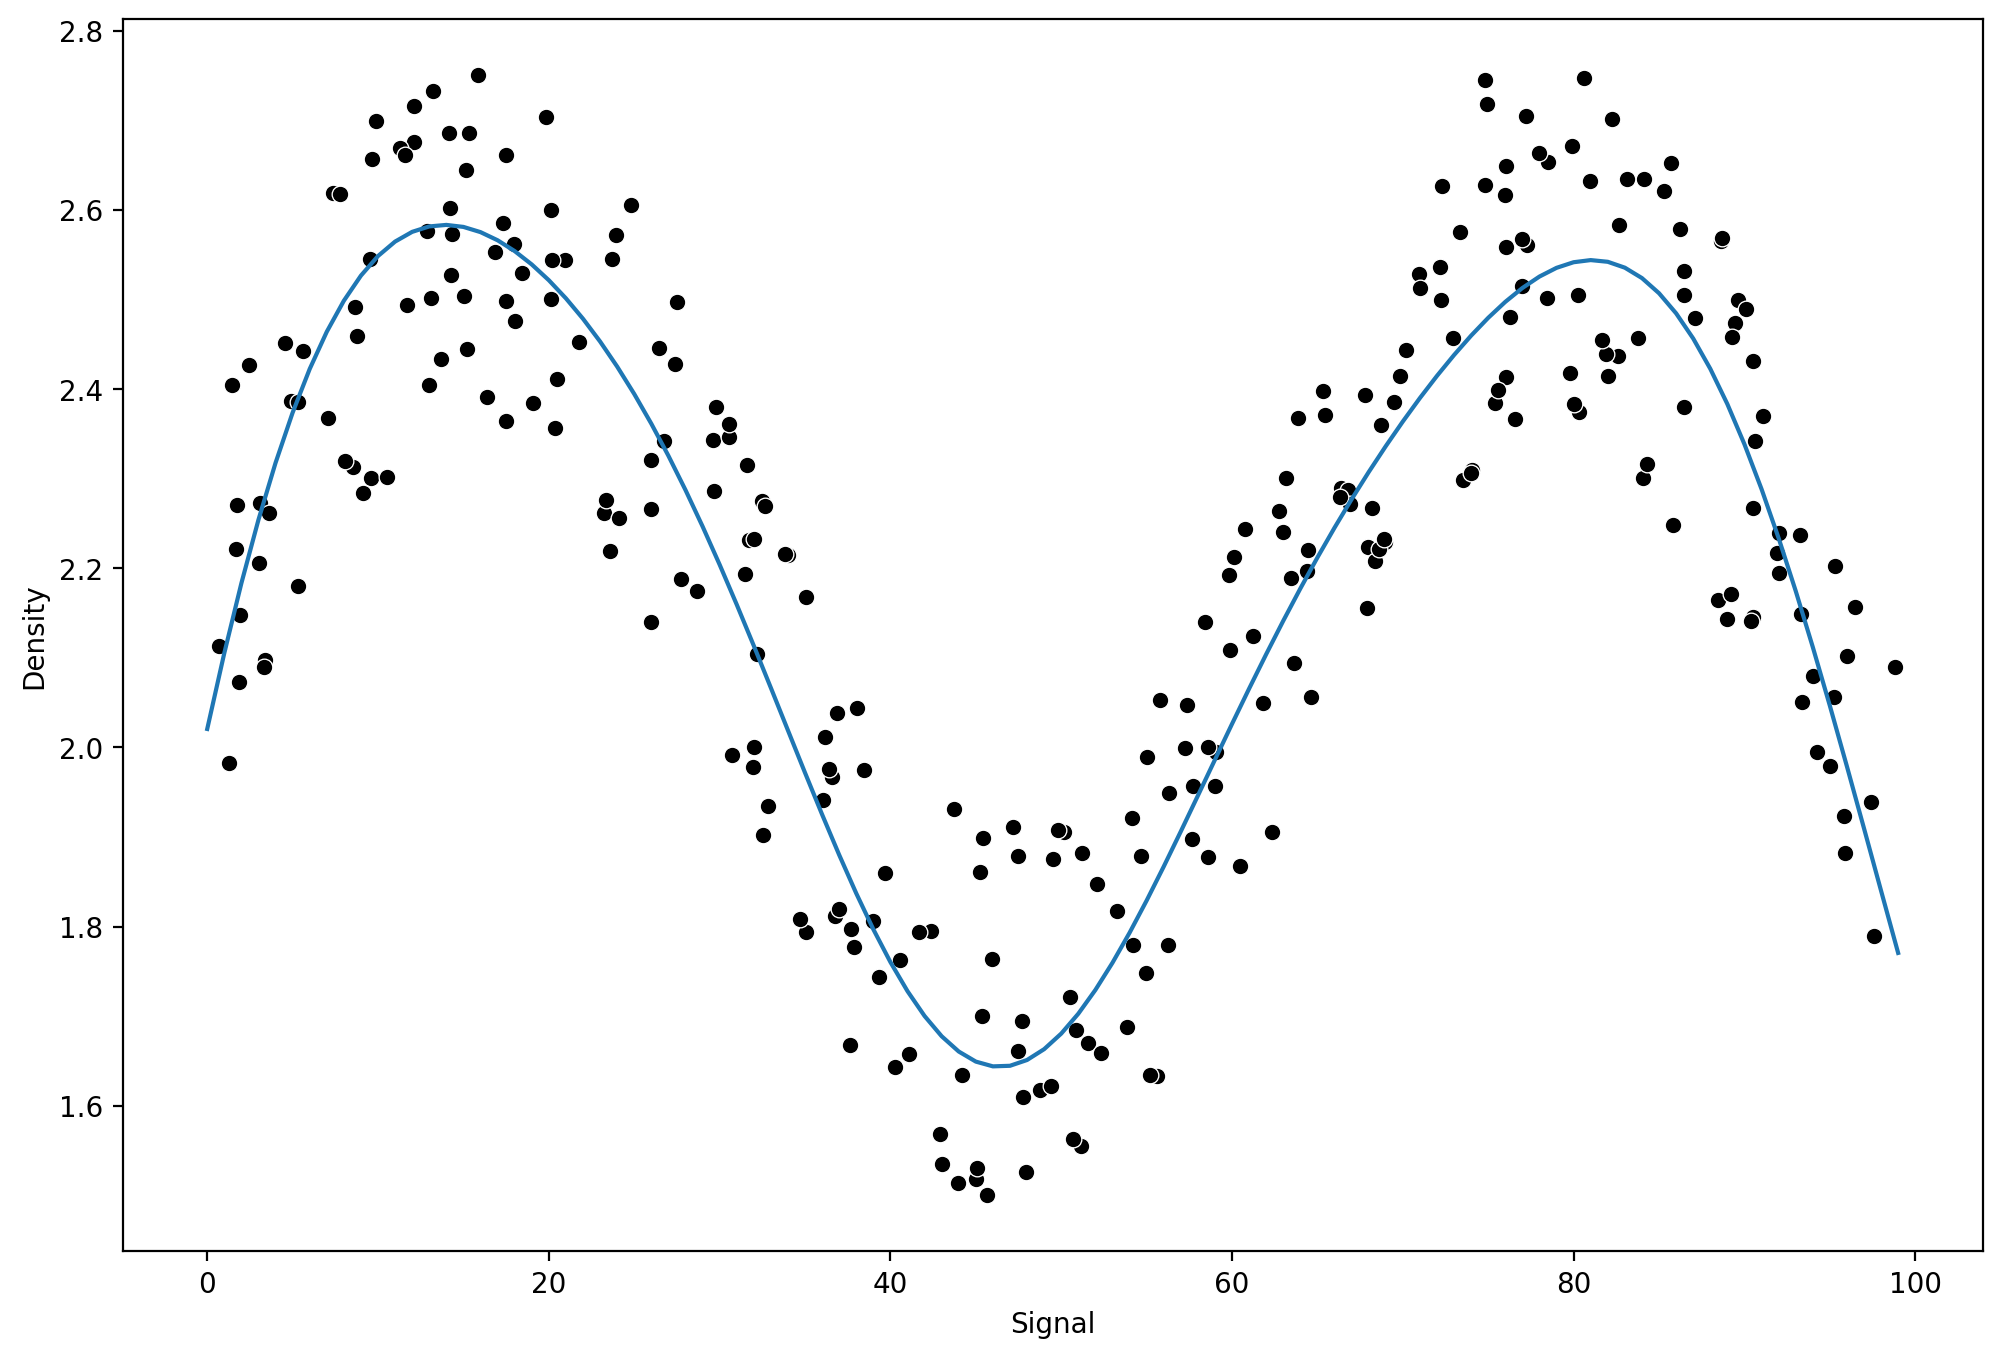

In [94]:
param_grid={
    "C":[0.01,0.1,1,1.5,5,10,100,1000],
    "gamma":['scale', 'auto']
}
grid=GridSearchCV(svr,param_grid )
run_model(grid,X_train,y_train,X_test,y_test)


In [95]:
from sklearn.ensemble import RandomForestRegressor

In [96]:
rfr=RandomForestRegressor(n_estimators=10)

MAE:0.13217240482251885
RMSE:0.16409384524764045


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


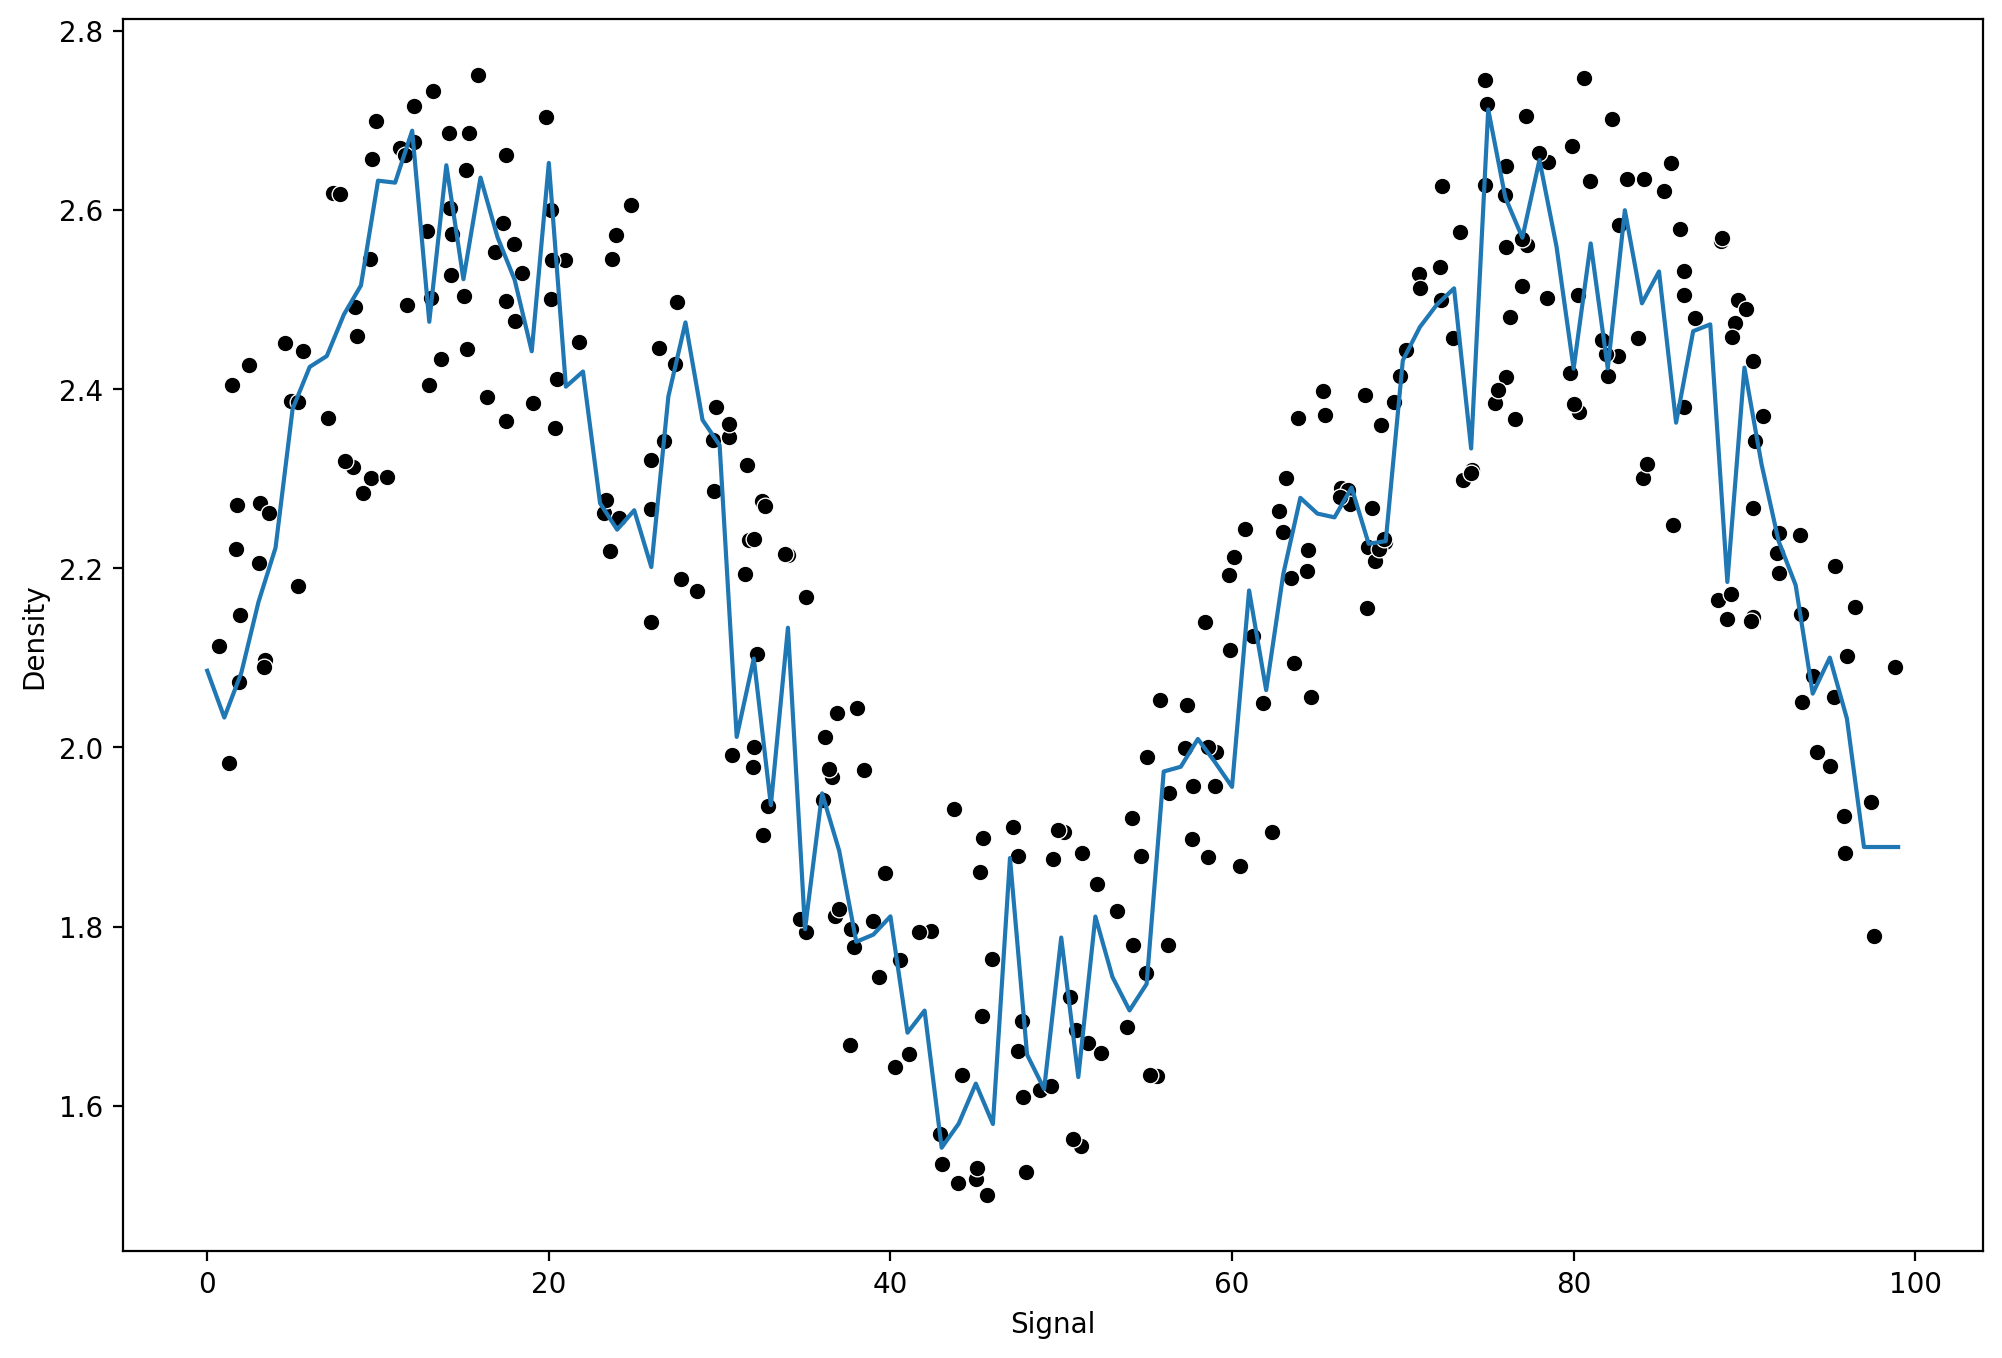

In [97]:
run_model(rfr,X_train,y_train,X_test,y_test)